In [1]:
import pandas as pd
from scipy.special import erfinv
from scipy.special import erf
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import numpy as np
import math

Part 1:

In [2]:
data = pd.read_table('Heat_Xfer_Lab_1.csv', delimiter=",")
data = data.apply(pd.to_numeric, errors="coerce")
data = data[data["Temperature"] <= 25]
data = data[data["Temperature"] >= 12.9]
T_air = 25
T_b = 12.9
d = .025
data['T*'] = (data["Temperature"]-T_b)/(T_air-T_b)
data = data[data["T*"] > 0]
data = data[data["T*"] < 1]
data = data[data["Time"] > 0]
data["alpha"] = (d**2)/(4*data["Time"]*(erfinv(data["T*"]))**2)
data["alpha"] =data["alpha"].replace([np.inf, -np.inf], np.nan)
data = data.dropna()
trial_1 = data[data["Trial"] == 1].copy()
trial_2 = data[data["Trial"] == 2].copy()
trial_3 = data[data["Trial"] == 3].copy()
trial_4 = data[data["Trial"] == 4].copy()
trial_5 = data[data["Trial"] == 5].copy()
trial_3.head()

,Trial,Time,Temperature,T*,alpha
1087,3.0,14.5,24.9,0.991736,0.000003
1089,3.0,15.5,24.9,0.991736,0.000003
1091,3.0,16.5,24.9,0.991736,0.000003
1114,3.0,28.0,24.9,0.991736,0.000002
1116,3.0,29.0,24.9,0.991736,0.000002


4.89428675562553e-06


c:\Users\gohus\anaconda3\envs\jr_labs\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in sqrt
  result = getattr(ufunc, method)(*inputs, **kwargs)


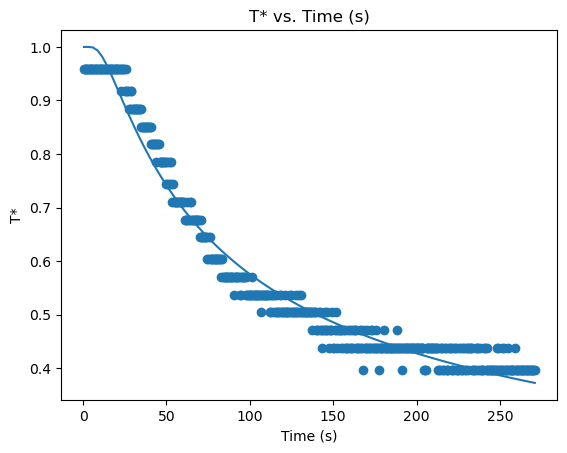

In [3]:
T_star_1 = trial_1["T*"]
t_1 = trial_1["Time"]
def model(t, alpha):
    return erf(d/(2*np.sqrt(alpha*t)))
popt, pcov = curve_fit(model, t_1, T_star_1)
alpha_fit_1 = popt[0]
print(alpha_fit_1)
x_fit_1 = np.linspace(min(trial_1["Time"]), max(trial_1["Time"]), 100)
y_fit_1 = model(x_fit_1, alpha_fit_1)
plt.scatter(trial_1["Time"], trial_1["T*"])
plt.plot(x_fit_1, y_fit_1)
plt.title("T* vs. Time (s)")
plt.ylabel('T*')
plt.xlabel("Time (s)")
plt.show()


4.447248999725935e-06


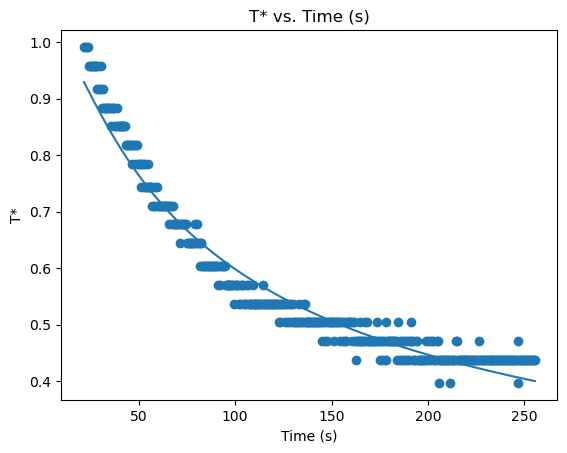

In [4]:
T_star_2 = trial_2["T*"]
t_2 = trial_2["Time"]
popt, pcov = curve_fit(model, t_2, T_star_2)
alpha_fit_2 = popt[0]
print(alpha_fit_2)
x_fit_2 = np.linspace(min(trial_2["Time"]), max(trial_2["Time"]), 100)
y_fit_2 = model(x_fit_2, alpha_fit_2)
plt.scatter(trial_2["Time"], trial_2["T*"])
plt.plot(x_fit_2, y_fit_2)
plt.title("T* vs. Time (s)")
plt.ylabel('T*')
plt.xlabel("Time (s)")
plt.show()

1.813417835712745e-06


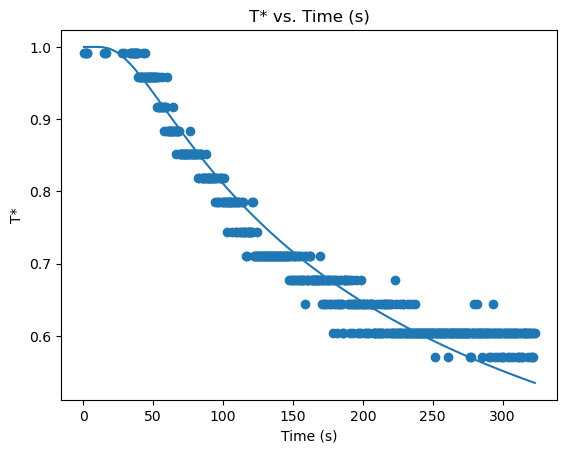

In [5]:
T_star_3 = trial_3["T*"]
t_3 = trial_3["Time"]
popt, pcov = curve_fit(model, t_3, T_star_3, p0=[1e-7],bounds=(0,np.inf))
alpha_fit_3 = popt[0]
print(alpha_fit_3)
x_fit_3 = np.linspace(min(trial_3["Time"]), max(trial_3["Time"]), 100)
y_fit_3 = model(x_fit_3, alpha_fit_3)
plt.scatter(trial_3["Time"], trial_3["T*"])
plt.plot(x_fit_3, y_fit_3)
plt.title("T* vs. Time (s)")
plt.ylabel('T*')
plt.xlabel("Time (s)")
plt.show()

1.8397041486344507e-06


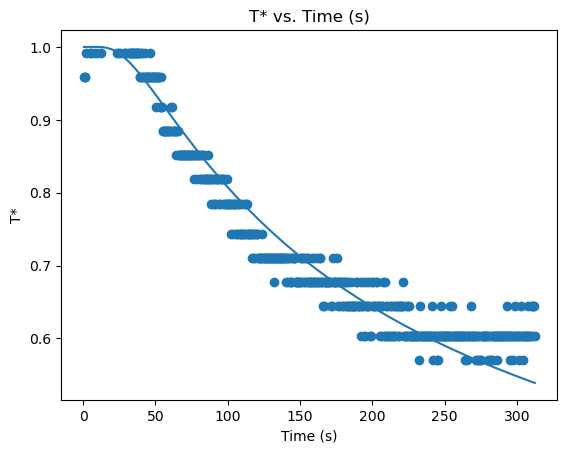

In [6]:
T_star_4 = trial_4["T*"]
t_4 = trial_4["Time"]
popt, pcov = curve_fit(model, t_4, T_star_4,p0=[1e-7],bounds=(0,np.inf))
alpha_fit_4 = popt[0]
print(alpha_fit_4)
x_fit_4 = np.linspace(min(trial_4["Time"]), max(trial_4["Time"]), 100)
y_fit_4 = model(x_fit_4, alpha_fit_4)
plt.scatter(trial_4["Time"], trial_4["T*"])
plt.plot(x_fit_4, y_fit_4)
plt.title("T* vs. Time (s)")
plt.ylabel('T*')
plt.xlabel("Time (s)")
plt.show()

1.909923201994757e-06


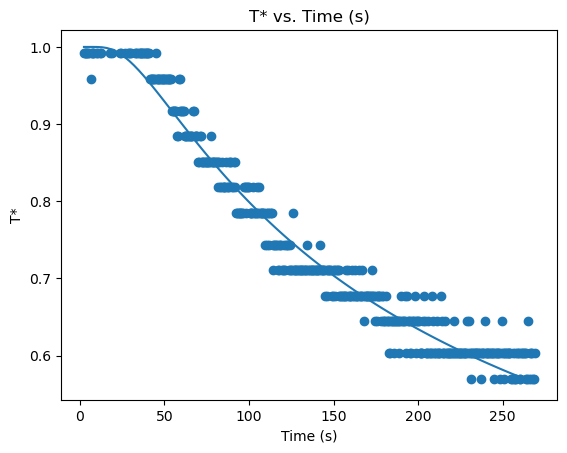

In [7]:
T_star_5 = trial_5["T*"]
t_5 = trial_5["Time"]
popt, pcov = curve_fit(model, t_5, T_star_5,p0=[1e-7],bounds=(0,np.inf))
alpha_fit_5 = popt[0]
print(alpha_fit_5)
x_fit_5 = np.linspace(min(trial_5["Time"]), max(trial_5["Time"]), 100)
y_fit_5 = model(x_fit_5, alpha_fit_5)
plt.scatter(trial_5["Time"], trial_5["T*"])
plt.plot(x_fit_5, y_fit_5)
plt.title("T* vs. Time (s)")
plt.ylabel('T*')
plt.xlabel("Time (s)")
plt.show()

In [8]:
#Disclosure, I used chatGPT as both a search engine for syntax in addition 
#to help me debug certain things. Mainly, setting parameters & bounds
#and fitting the line. It told me to use p0 to make an initial guess for the fit

In [9]:
#alpha_mean_1 = np.mean(trial_1["alpha"])
#print("Trial 1 Mean: ",alpha_mean_1)
#alpha_mean_2 = np.mean(trial_2["alpha"])
#print("Trial 2 Mean: ",alpha_mean_2)
#alpha_mean_3 = np.mean(trial_3["alpha"])
#print("Trial 3 Mean: ",alpha_mean_3)
#alpha_mean_4 = np.mean(trial_4["alpha"])
#print("Trial 4 Mean: ",alpha_mean_4)
#alpha_mean_5 = np.mean(trial_5["alpha"])
#print("Trial 5 Mean: ",alpha_mean_5)
mean_alpha_total=np.mean([alpha_fit_1,alpha_fit_2,alpha_fit_3,alpha_fit_4,alpha_fit_5])
print("Total Alpha Mean: ",mean_alpha_total)

Total Alpha Mean:  2.9809161883386836e-06


In [10]:
#alpha_std_1 = np.std(trial_1["alpha"])
#print("Trial 1 STD: ",alpha_std_1)
#alpha_std_2 = np.std(trial_2["alpha"])
#print("Trial 2 STD: ",alpha_std_2)
#alpha_std_3 = np.std(trial_3["alpha"])
#print("Trial 3 STD: ",alpha_std_3)
#alpha_std_4 = np.std(trial_4["alpha"])
#print("Trial 4 STD: ",alpha_std_4)
#alpha_std_5 = np.std(trial_5["alpha"])
#print("Trial 5 STD: ",alpha_std_5)
#alpha_std_total=np.mean([alpha_std_1,alpha_std_2,alpha_std_3,alpha_std_4,alpha_std_5])
alpha_fits = np.array([alpha_fit_1,alpha_fit_2, alpha_fit_3, alpha_fit_4, alpha_fit_5])
alpha_std = np.std(alpha_fits, ddof=1)
print("Alpha STD Total: ",alpha_std)

Alpha STD Total:  1.5510933354619965e-06


In [11]:
#K values
k_avg_1 = alpha_fit_1*2701*902
k_avg_2 = alpha_fit_2*2701*902
k_avg_3 = alpha_fit_3*2701*902
k_avg_4 = alpha_fit_4*2701*902
k_avg_5 = alpha_fit_5*2701*902
print("k avg 1: ",k_avg_1)
print("k avg 2: ",k_avg_2)
print("k avg 3: ",k_avg_3)
print("k avg 4: ",k_avg_4)
print("k avg 5: ",k_avg_5)
k_avg_total=np.mean([k_avg_1,k_avg_2,k_avg_3,k_avg_4,k_avg_5])
print("k Average Total: ",k_avg_total)

k avg 1:  11.92396061130399
k avg 2:  10.834841632530296
k avg 3:  4.4180334999826325
k avg 4:  4.4820748967264095
k avg 5:  4.65314971686623
k Average Total:  7.262412071481911


In [12]:
k_std = np.std([k_avg_1,k_avg_2,k_avg_3,k_avg_4,k_avg_5])
print(k_std)

3.3799793507155025


Part 2:

In [13]:
tc = {"Distance (cm)": [10, 9, 8, 7, 6, 5, 4, 3, 2, 1, 0], "Fin Temp (C)": [24.7,
24.4, 23.4, 23, 21.6, 21, 19.8, 18.7, 16.5, 15.5, 12.9]}
thermocouple = pd.DataFrame(data=tc)
thermocouple

,Distance (cm),Fin Temp (C)
0,10,24.7
1,9,24.4
2,8,23.4
3,7,23.0
4,6,21.6
5,5,21.0
6,4,19.8
7,3,18.7
8,2,16.5
9,1,15.5


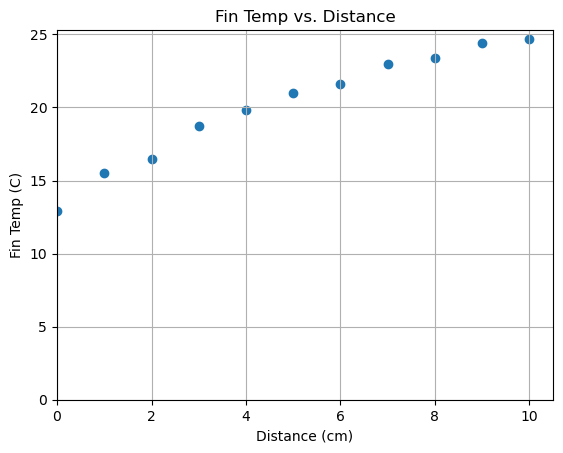

In [14]:
plt.scatter(thermocouple["Distance (cm)"], thermocouple["Fin Temp (C)"])
plt.ylim(bottom=0)
plt.xlim(left=0)
plt.grid(which='major')
plt.title("Fin Temp vs. Distance")
plt.ylabel('Fin Temp (C)')
plt.xlabel("Distance (cm)")
plt.show()

In [15]:
fin_T = thermocouple["Fin Temp (C)"].astype(float)
T_i = thermocouple["Fin Temp (C)"].apply(pd.to_numeric,errors="coerce")[10]
ln = np.log((fin_T-25)/(T_i-25))

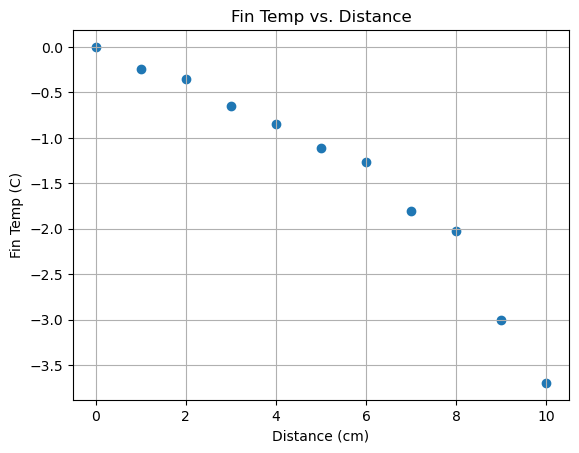

In [16]:
plt.scatter(thermocouple["Distance (cm)"], ln)
plt.grid(which='major')
plt.title("Fin Temp vs. Distance")
plt.ylabel('Fin Temp (C)')
plt.xlabel("Distance (cm)")
plt.show()

In [17]:
dist = thermocouple["Distance (cm)"].to_numpy()[0:6]
dist_ln = np.log((fin_T-25)/(T_i-25))[0:6]
fin_fit, b = np.polyfit(dist, dist_ln, 1)
print("fin fit:", fin_fit)
fin_area = 8.064 #mm^2
fin_perimeter = 42.768 #mm
print("K:",k_avg_total)
h = 10 * fin_fit**2 * k_avg_total * fin_area / fin_perimeter
print("h:",h)

fin fit: -0.5250937869916469
K: 7.262412071481911
h: 3.7756021462523175


In [18]:
q_f = np.sqrt(k_avg_total*fin_perimeter*h*fin_area)*(25-12.9)*10**-4.5
print("q_f: ",q_f)

q_f:  0.03720948475783819


In [19]:
effectiveness = q_f*(10**6)/(h*fin_area*(25-12.9))
print("Effectiveness: ",effectiveness)

Effectiveness:  101.00236491001935


In [20]:
cup_area = 4.25**2*math.pi
incr_factor = 1 + effectiveness*(fin_area/cup_area)
print("Increase Factor: ",incr_factor)

Increase Factor:  15.353384831128524
